# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

Text(0, 0.5, 'Adverts')

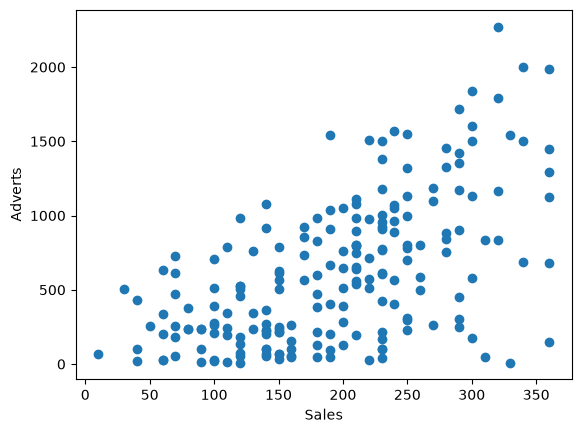

In [ ]:
# Code here
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("album_sales.csv")


plt.scatter(df["sales"], df["adverts"])
plt.xlabel("Sales")
plt.ylabel("Adverts")


Text(0, 0.5, 'Attract')

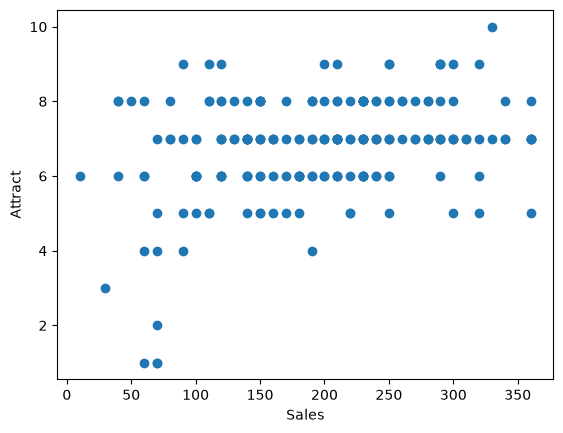

In [ ]:
plt.scatter(df["sales"], df["attract"])
plt.xlabel("Sales")
plt.ylabel("Attract")

Text(0, 0.5, 'Airplay')

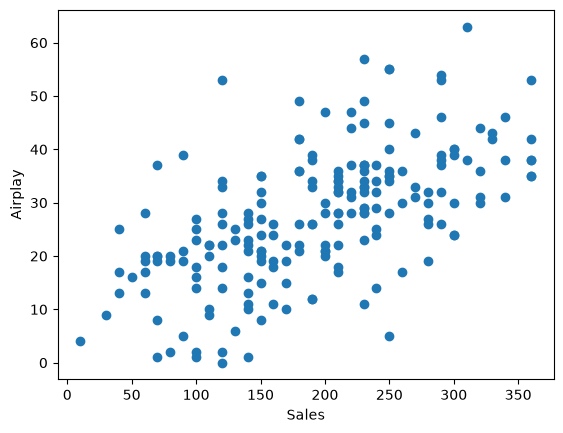

In [ ]:
plt.scatter(df["sales"], df["airplay"])
plt.xlabel("Sales")
plt.ylabel("Airplay")

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

The scatterplots show a positive relationship between sales and advertising, sales and airplay, and sales and attractiveness. Advertising appears to have the strongest relationship, while attractiveness is weaker. Overall, as each predictor increases, album sales tend to increase.

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [18]:
# Code here
x = df['adverts']
y = df['sales']
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x) # will be used later
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        15:02:58   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The F-statistic tests whether the regression model as a whole explains a significant amount of variation in sales. The p-value is less than 0.05, which means the model is statistically significant. This shows that advertising has a meaningful relationship with album sales. A low p-value does not mean the model is perfect, but it does show that the model is useful for predicting sales better than a no relationship model.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [19]:
# Code here
x = df[['adverts']]
y = df['sales']
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

b0 = model.params['const']
b1 = model.params['adverts']
predicted_sales = b0 + b1 * 135

print("Intercept: ", b0)
print("Advertising coefficient: ", b1)
print("Predicted album sales for $135,000 advertising: ", predicted_sales)

Intercept:  134.13993781207427
Advertising coefficient:  0.09612448597387711
Predicted album sales for $135,000 advertising:  147.11674341854768


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [20]:
# Code here
x = df[['adverts', 'airplay', 'attract']]
y = df.sales
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x) # will be used later
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        15:03:05   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.
`
Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

Model 2 is better because it includes more predictors and should have a higher R-squared value. Since it also has a p-value below 0.05, it is statistically significant. This means the multiple regression model fits the data better and is a stronger model for predicting album sales.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name